<a href="https://colab.research.google.com/github/mahdics313-AIOps/ECG-Arrhythmia-Classification/blob/main/ECG_Arrhythmia_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECG Arrhythmia Classification using a Hybrid Autoencoder-CNN Model

---

## Educational Notebook for ECG Signal Analysis

این Notebook با هدف پیاده‌سازی مقاله زیر تهیه شده است.

در طول پروژه، علاوه بر نوشتن کد، تلاش می‌کنیم دلیل انجام هر مرحله و ارتباط آن با مقاله را نیز بررسی کنیم.

---

**Paper**

Hybrid Autoencoder-CNN Model for Accurate ECG Arrhythmia Classification Using the MIT-BIH Dataset

IEEE GCWCN 2025

---

**Author**

Nazanin Sarabi

Master's Student in Biomedical Engineering

---

**Notebook Version**

v1.0

# 1. Project Overview

هدف این پروژه، پیاده‌سازی گام‌به‌گام مدل معرفی‌شده در مقاله و آشنایی با مراحل اصلی طبقه‌بندی آریتمی قلبی از روی سیگنال ECG است.

در این Notebook تلاش می‌کنیم هر مرحله را به‌صورت آموزشی بررسی کنیم تا علاوه بر اجرای کد، دلیل انجام هر بخش نیز کاملاً روشن باشد.

در پایان این پروژه، با مراحل زیر آشنا خواهید شد:

- آشنایی با دیتاست MIT-BIH
- بررسی سیگنال ECG
- تحلیل فایل‌های Annotation
- پیش‌پردازش سیگنال
- استخراج ضربان‌های قلب
- آماده‌سازی داده برای مدل
- آموزش Autoencoder
- آموزش CNN
- ساخت مدل Hybrid
- ارزیابی عملکرد مدل
- مقایسه نتایج با مقاله

# 2. About the Paper

در این مقاله، نویسندگان یک مدل ترکیبی شامل دو بخش اصلی پیشنهاد کرده‌اند.

بخش اول یک Autoencoder است که ویژگی‌های مهم سیگنال ECG را یاد می‌گیرد و نویزهای غیرضروری را کاهش می‌دهد.

بخش دوم یک شبکه CNN است که با استفاده از این ویژگی‌ها، نوع هر ضربان قلب را تشخیص می‌دهد.

هدف این ترکیب، افزایش دقت طبقه‌بندی آریتمی‌های قلبی نسبت به استفاده از یک CNN معمولی است.

در طول این Notebook، تلاش می‌کنیم همین روند را به‌صورت مرحله‌به‌مرحله پیاده‌سازی کنیم.

# Roadmap

در طول این پروژه، Notebook به‌صورت مرحله‌به‌مرحله تکمیل خواهد شد.

در هر بخش، علاوه بر پیاده‌سازی کد، دلیل انجام آن مرحله و ارتباط آن با مقاله نیز بررسی می‌شود.

مراحل اصلی پروژه عبارت‌اند از:

1. Project Overview

2. About the Paper

3. Dataset Introduction

4. ECG Signal Exploration

5. Annotation Analysis

6. Signal Preprocessing

7. Heartbeat Segmentation

8. Dataset Preparation

9. Autoencoder

10. CNN Classifier

11. Hybrid Autoencoder-CNN

12. Model Evaluation

13. Reproducing the Paper Results

14. Conclusion

# 3. Dataset Introduction

در این بخش با دیتاست مورد استفاده در مقاله آشنا می‌شویم.

تمام آزمایش‌های مقاله بر روی دیتاست MIT-BIH Arrhythmia Database انجام شده‌اند.

این دیتاست یکی از شناخته‌شده‌ترین مجموعه‌داده‌های حوزه تحلیل سیگنال ECG است و سال‌هاست به‌عنوان مرجع بسیاری از پژوهش‌های تشخیص آریتمی استفاده می‌شود.

هر رکورد این دیتاست شامل سه فایل اصلی است:

- فایل Header که اطلاعات کلی رکورد را نگهداری می‌کند.
- فایل Signal که سیگنال ECG را ذخیره می‌کند.
- فایل Annotation که محل و نوع ضربان‌های قلب را مشخص می‌کند.

در ادامه ابتدا یکی از رکوردهای این دیتاست را بارگذاری می‌کنیم.

In [ ]:
# Import required libraries

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import wfdb

کتابخانه WFDB ابزار رسمی پروژه PhysioNet برای خواندن دیتاست‌های پزشکی است.

از آنجا که دیتاست MIT-BIH با همین قالب منتشر شده است، استفاده از این کتابخانه مطمئن‌ترین روش برای خواندن فایل‌ها محسوب می‌شود.

در این پروژه نیز از همین کتابخانه استفاده خواهیم کرد.

In [ ]:
# Define dataset path

DATA_DIR = Path("../data/raw")

In [ ]:
# Load one ECG record

record = wfdb.rdrecord(str(DATA_DIR / "100"))

record

شیء بالا تمام اطلاعات مربوط به رکورد شماره 100 را در اختیار ما قرار می‌دهد.

در ادامه، مهم‌ترین ویژگی‌های این رکورد را بررسی می‌کنیم تا با ساختار داده آشنا شویم.

In [ ]:
# Display signal shape

record.p_signal.shape

(650000, 2)

خروجی بالا تعداد نمونه‌های سیگنال و تعداد کانال‌های ثبت‌شده را نشان می‌دهد.

در دیتاست MIT-BIH معمولاً هر رکورد شامل دو کانال ECG است.

در این پروژه، مطابق مقاله، تنها از کانال اول استفاده خواهیم کرد.

In [ ]:
# Display sampling frequency

record.fs

360

نرخ نمونه‌برداری این دیتاست برابر با 360 هرتز است.

این یعنی در هر ثانیه، 360 نمونه از سیگنال ECG ثبت شده است.

این مقدار در مراحل بعدی، هنگام استخراج ضربان‌های قلب و تقسیم سیگنال به بازه‌های زمانی، اهمیت زیادی خواهد داشت.

In [ ]:
# Display channel names

record.sig_name

['MLII', 'V5']

این خروجی نام کانال‌های ثبت‌شده را نشان می‌دهد.

برای ساده‌تر شدن مراحل بعدی، تنها کانال اول را انتخاب می‌کنیم؛ زیرا مقاله نیز از یک سیگنال برای آموزش مدل استفاده کرده است.

# 4. ECG Signal Exploration

در این بخش برای اولین بار سیگنال واقعی ECG را مشاهده می‌کنیم.

هدف این قسمت، آشنایی با شکل کلی سیگنال است؛ بنابراین هنوز وارد تحلیل برچسب‌ها (Annotationها) یا استخراج ضربان‌ها نمی‌شویم.

اگر ابتدا ظاهر سیگنال را بشناسیم، درک مراحل بعدی مانند پیش‌پردازش، استخراج ضربان‌ها و آموزش مدل بسیار ساده‌تر خواهد بود.

---

## Learning Objectives

پس از پایان این بخش خواهید توانست:

- سیگنال ECG را از دیتاست MIT-BIH نمایش دهید.
- محورهای نمودار را تفسیر کنید.
- چرخه‌های تکرارشونده قلب را در سیگنال مشاهده کنید.
- محل تقریبی قله‌های R را تشخیص دهید.

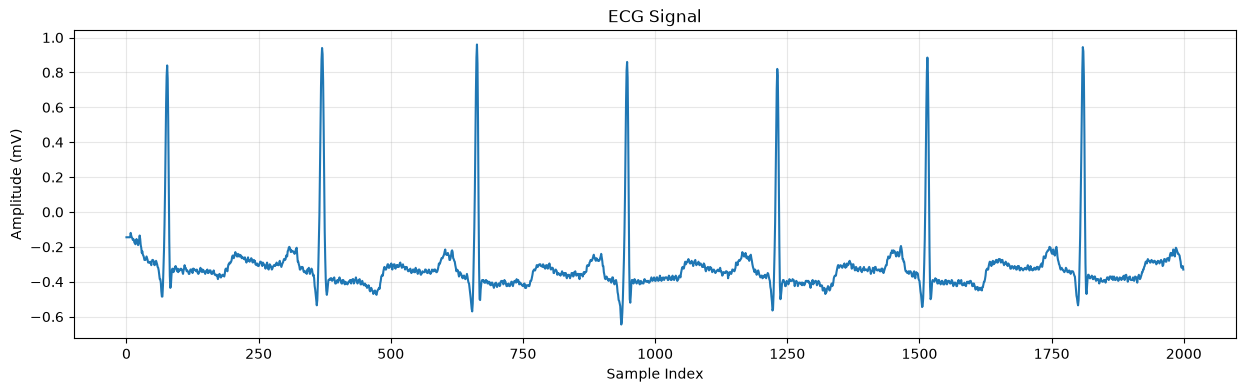

In [ ]:
# Plot the first part of the ECG signal

plt.figure(figsize=(15, 4))

plt.plot(record.p_signal[:2000, 0])

plt.title("ECG Signal")

plt.xlabel("Sample Index")

plt.ylabel("Amplitude (mV)")

plt.grid(alpha=0.3)

plt.show()

در نمودار بالا، تنها بخش کوچکی از رکورد شماره **100** نمایش داده شده است.

در این مرحله فقط کافی است شکل کلی سیگنال را مشاهده کنید.

اگر با دقت به نمودار نگاه کنید، متوجه می‌شوید که الگوهای مشابهی به‌صورت متوالی تکرار می‌شوند. هر الگو نمایانگر یک چرخه از فعالیت الکتریکی قلب است.

در مراحل بعدی یاد خواهیم گرفت که چگونه این چرخه‌ها را به‌صورت خودکار استخراج کنیم.

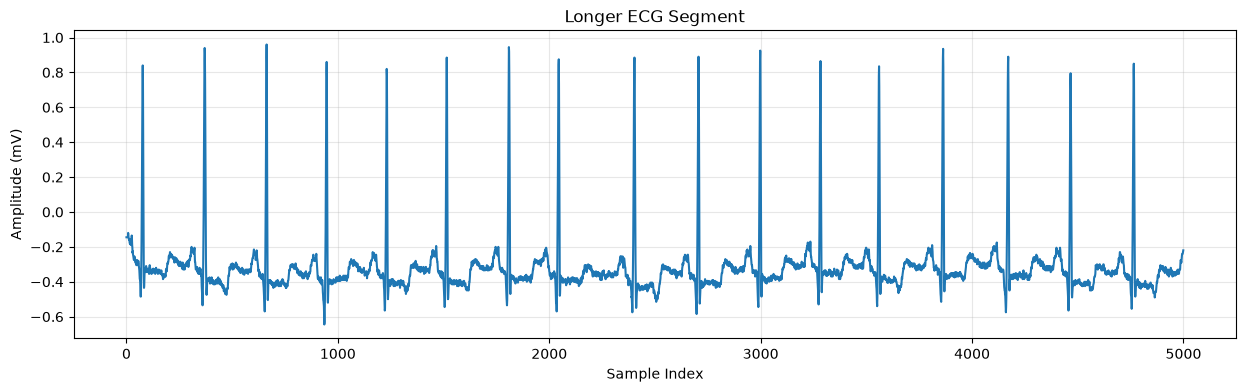

In [ ]:
# Display a longer ECG segment

plt.figure(figsize=(15, 4))

plt.plot(record.p_signal[:5000, 0])

plt.title("Longer ECG Segment")

plt.xlabel("Sample Index")

plt.ylabel("Amplitude (mV)")

plt.grid(alpha=0.3)

plt.show()

نمایش بخش طولانی‌تر سیگنال، دید بهتری نسبت به رفتار کلی قلب ایجاد می‌کند.

در این نمودار می‌توان مشاهده کرد که بیشتر چرخه‌های قلبی شکل مشابهی دارند، اما ممکن است در برخی نقاط تفاوت‌هایی نیز دیده شود.

وجود این تفاوت‌ها یکی از دلایلی است که تشخیص خودکار آریتمی را به یک مسئله مهم در یادگیری ماشین تبدیل می‌کند.

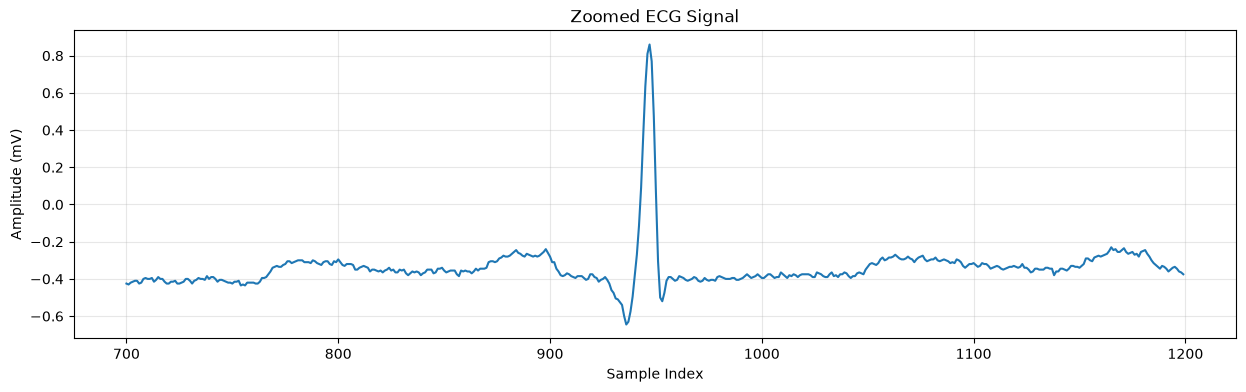

In [ ]:
# Zoom in on a small ECG segment

start = 700
end = 1200

plt.figure(figsize=(15, 4))

plt.plot(
    range(start, end),
    record.p_signal[start:end, 0]
)

plt.title("Zoomed ECG Signal")

plt.xlabel("Sample Index")

plt.ylabel("Amplitude (mV)")

plt.grid(alpha=0.3)

plt.show()

در این بزرگ‌نمایی، ساختار هر چرخه قلبی واضح‌تر دیده می‌شود.

در هر چرخه معمولاً یک قله بلند مشاهده می‌شود که به آن **قله R (R-Peak)** گفته می‌شود.

در این Notebook هنوز این قله‌ها را به‌صورت خودکار استخراج نمی‌کنیم؛ زیرا ابتدا لازم است با فایل‌های Annotation دیتاست آشنا شویم.

در بخش بعدی، محل دقیق این قله‌ها را با استفاده از اطلاعات ثبت‌شده توسط متخصصان قلب بررسی خواهیم کرد.

## Key Takeaways

در این بخش:

- با شکل کلی سیگنال ECG آشنا شدیم.
- چند بازه مختلف از سیگنال را مشاهده کردیم.
- مفهوم چرخه قلبی را مرور کردیم.
- محل تقریبی قله‌های R را در نمودار تشخیص دادیم.

در بخش بعدی (**Annotation Analysis**) از فایل‌های Annotation استفاده خواهیم کرد تا محل دقیق هر ضربان قلب و نوع آن را بررسی کنیم.

---
---

# 5. Annotation Analysis

در این بخش، برای اولین بار فایل Annotation مربوط به رکورد ECG را بررسی می‌کنیم.

هر رکورد در دیتاست MIT-BIH علاوه بر سیگنال ECG، دارای فایل Annotation نیز هست. این فایل توسط متخصصان قلب تهیه شده و محل وقوع هر ضربان قلب و نوع آن را مشخص می‌کند.

در واقع، این Annotationها همان برچسب‌های مرجع (Ground Truth) هستند که مدل یادگیری ماشین باید آن‌ها را یاد بگیرد.

---

## Learning Objectives

پس از پایان این بخش خواهید توانست:

- فایل Annotation را بارگذاری کنید.
- ساختار Annotation را بشناسید.
- تفاوت Sample و Symbol را توضیح دهید.
- تعداد Annotationهای موجود در هر رکورد را بررسی کنید.
- اولین تحلیل آماری برچسب‌ها را انجام دهید.

In [ ]:
# Load annotation file

annotation = wfdb.rdann(
    str(DATA_DIR / "100"),
    "atr"
)

annotation

خروجی این سلول یک شیء از نوع **WFDB Annotation** است.

این شیء شامل اطلاعات مختلفی درباره رویدادهای ثبت‌شده در سیگنال ECG است.

در این Notebook بیشتر از دو ویژگی مهم آن استفاده خواهیم کرد:

- **sample**: محل وقوع هر رویداد در سیگنال
- **symbol**: نوع ضربان یا رویداد ثبت‌شده

In [ ]:
# Display basic annotation information

print("Number of annotations :", len(annotation.sample))

print("\nFirst 10 sample indices:")
print(annotation.sample[:10])

print("\nFirst 10 beat symbols:")
print(annotation.symbol[:10])

Number of annotations : 2274

First 10 sample indices:
[  18   77  370  662  946 1231 1515 1809 2044 2402]

First 10 beat symbols:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


در خروجی بالا دو نوع اطلاعات مهم مشاهده می‌کنید.

### Sample Index

شماره نمونه‌ای است که ضربان قلب در آن ثبت شده است.

از آنجا که نرخ نمونه‌برداری دیتاست برابر با **360 هرتز** است، در صورت نیاز می‌توان موقعیت زمانی هر ضربان را نیز از روی شماره نمونه محاسبه کرد.

---

### Beat Symbol

این مقدار نوع هر ضربان قلب را مشخص می‌کند.

برای مثال، نماد **N** نشان‌دهنده ضربان طبیعی قلب است.

در مراحل بعدی با سایر نمادهای مهم نیز آشنا خواهیم شد.

In [ ]:
# Create annotation table

annotation_df = pd.DataFrame(
    {
        "sample": annotation.sample,
        "symbol": annotation.symbol,
    }
)

annotation_df.head(10)

,sample,symbol
0,18,+
1,77,N
2,370,N
3,662,N
4,946,N
5,1231,N
6,1515,N
7,1809,N
8,2044,A
9,2402,N


استفاده از DataFrame باعث می‌شود اطلاعات Annotation راحت‌تر بررسی شوند.

از این مرحله به بعد، بیشتر تحلیل‌های آماری و تصویری را بر پایه همین جدول انجام خواهیم داد.

این روش علاوه بر خوانایی بیشتر کد، امکان استفاده از ابزارهای تحلیلی کتابخانه Pandas را نیز فراهم می‌کند.

In [ ]:
# Count beat symbols

beat_counts = annotation_df["symbol"].value_counts()

beat_counts

symbol
N    2239
A      33
+       1
V       1
Name: count, dtype: int64

در این جدول مشاهده می‌کنید که تمام Annotationها مربوط به ضربان قلب نیستند.

برخی نمادها برای رویدادهای دیگر مانند تغییر ریتم یا علامت‌های کنترلی استفاده می‌شوند.

در پروژه‌های طبقه‌بندی آریتمی، معمولاً فقط نمادهای مربوط به ضربان قلب انتخاب می‌شوند و سایر Annotationها کنار گذاشته می‌شوند.

در ادامه نیز مطابق روند مقاله، روی ضربان‌های قلب تمرکز خواهیم کرد.

## Beat Class Distribution

در این بخش، تعداد وقوع هر نوع ضربان قلب را بررسی می‌کنیم.

هدف این نمودار، آشنایی با توزیع برچسب‌های موجود در دیتاست است.

در بسیاری از مسائل یادگیری ماشین پزشکی، همه کلاس‌ها تعداد نمونه یکسانی ندارند. به همین دلیل، بررسی توزیع کلاس‌ها یکی از اولین مراحل تحلیل داده محسوب می‌شود.

در ادامه مشاهده خواهیم کرد که برخی از انواع ضربان قلب بسیار بیشتر از سایر کلاس‌ها در دیتاست حضور دارند.

In [ ]:
# Count beat symbols

beat_counts = annotation_df["symbol"].value_counts()

beat_counts

symbol
N    2239
A      33
+       1
V       1
Name: count, dtype: int64

خروجی این سلول تعداد هر نوع ضربان قلب را نشان می‌دهد.

در ستون سمت چپ، نماد هر ضربان (Symbol) و در ستون سمت راست، تعداد نمونه‌های همان کلاس نمایش داده شده است.

در مرحله بعد این اطلاعات را به صورت نمودار رسم می‌کنیم تا مقایسه کلاس‌ها ساده‌تر شود.

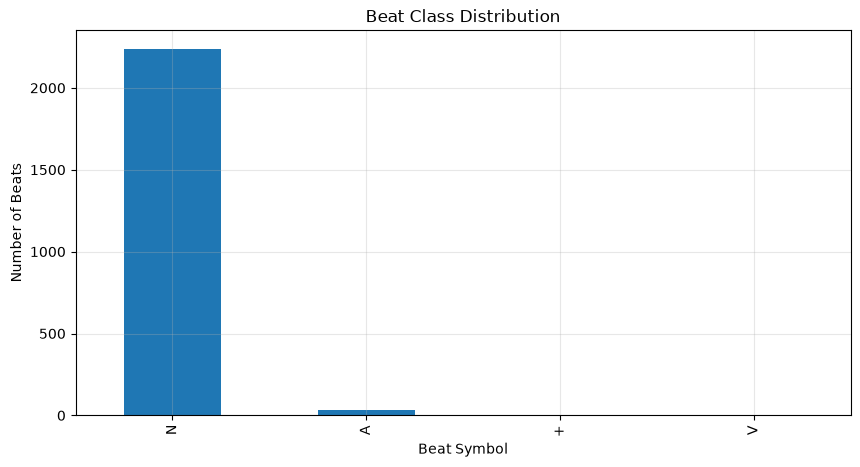

In [ ]:
# Plot beat class distribution

plt.figure(figsize=(10, 5))

beat_counts.plot(kind="bar")

plt.title("Beat Class Distribution")

plt.xlabel("Beat Symbol")

plt.ylabel("Number of Beats")

plt.grid(alpha=0.3)

plt.show()

## What do we observe?

در این نمودار مشاهده می‌کنیم که توزیع کلاس‌ها یکنواخت نیست.

به عنوان مثال، ضربان طبیعی (**Normal Beat**) تعداد بسیار بیشتری نسبت به بسیاری از ضربان‌های غیرطبیعی دارد.

این وضعیت با عنوان **عدم توازن کلاس‌ها (Class Imbalance)** شناخته می‌شود.

در این Notebook فعلاً تنها این ویژگی را مشاهده می‌کنیم و در مراحل مربوط به آموزش مدل، درباره تأثیر آن بر عملکرد شبکه عصبی بیشتر صحبت خواهیم کرد.

## ECG Signal with Beat Annotations

اکنون محل دقیق ضربان‌های ثبت‌شده را روی خود سیگنال ECG نمایش می‌دهیم.

هر نقطه قرمز، محل یک Annotation است که توسط متخصصان روی سیگنال ثبت شده است.

این برچسب‌ها مرجع اصلی (Ground Truth) برای آموزش و ارزیابی مدل خواهند بود.

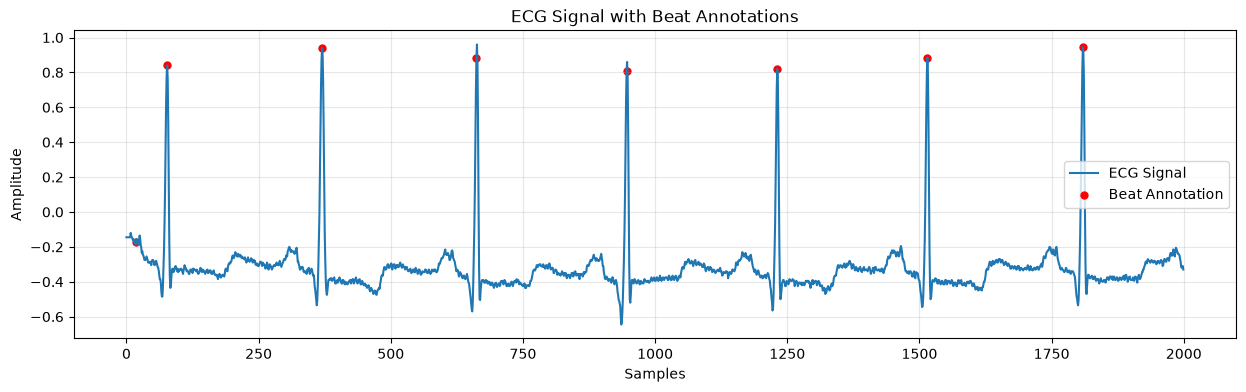

In [ ]:
# Plot ECG signal with beat annotations

signal = record.p_signal[:, 0]

start = 0
end = 2000

plt.figure(figsize=(15, 4))

plt.plot(signal[start:end], label="ECG Signal")

samples = annotation.sample
samples = samples[(samples >= start) & (samples <= end)]

plt.scatter(
    samples,
    signal[samples],
    color="red",
    s=25,
    label="Beat Annotation",
)

plt.title("ECG Signal with Beat Annotations")

plt.xlabel("Samples")

plt.ylabel("Amplitude")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## What do we observe?

در این شکل، سیگنال ECG به همراه محل Annotationها نمایش داده شده است.

نقاط قرمز محل وقوع ضربان‌هایی هستند که توسط متخصصان قلب برچسب‌گذاری شده‌اند.

دقت کنید که همه قله‌های سیگنال لزوماً به یک نوع ضربان تعلق ندارند؛ نوع هر ضربان توسط فایل Annotation مشخص می‌شود.

در ادامه پروژه، از همین Annotationها برای استخراج ضربان‌های منفرد و ساخت مجموعه داده آموزشی استفاده خواهیم کرد.

با پایان این بخش، اکنون هم با شکل سیگنال ECG آشنا هستیم و هم ساختار برچسب‌های دیتاست را می‌شناسیم. این شناخت، پایه ورود به مرحله پیش‌پردازش سیگنال خواهد بود.

---
---

# 6. Signal Preprocessing

تا اینجا سیگنال ECG را مشاهده کردیم و با ساختار Annotationهای دیتاست آشنا شدیم.

اکنون زمان آن رسیده است که سیگنال را برای مراحل بعدی آماده کنیم.

در مسائل پردازش سیگنال پزشکی، معمولاً داده خام مستقیماً وارد مدل یادگیری ماشین نمی‌شود. ابتدا باید کیفیت سیگنال بررسی شود و در صورت نیاز، عملیات پیش‌پردازش روی آن انجام گیرد.

در این Notebook نیز مطابق روند مقاله، به‌صورت مرحله‌به‌مرحله داده را برای استخراج ضربان‌های قلب آماده خواهیم کرد.

---

## Learning Objectives

پس از پایان این بخش خواهید توانست:

- هدف پیش‌پردازش سیگنال ECG را توضیح دهید.
- نقش نرخ نمونه‌برداری (Sampling Frequency) را در تحلیل سیگنال درک کنید.
- بازه زمانی متناظر با نمونه‌های سیگنال را محاسبه کنید.
- سیگنال را برای مرحله استخراج ضربان‌ها آماده کنید.

### Why do we need preprocessing?

در بسیاری از سیگنال‌های پزشکی، ممکن است نویز، تغییرات خط پایه یا سایر اختلالات وجود داشته باشد.

در این پروژه، قبل از استخراج ضربان‌های قلب، ابتدا اطلاعات پایه سیگنال را بررسی می‌کنیم تا بدانیم داده با چه مشخصاتی ثبت شده است.

این اطلاعات در مراحل بعدی برای انتخاب اندازه پنجره هر ضربان و تفسیر نتایج اهمیت خواهند داشت.

In [ ]:
# Display recording information

print("Sampling frequency (Hz):", record.fs)

print("Number of samples:", record.sig_len)

print("Signal duration (seconds):", record.sig_len / record.fs)

print("Available channels:", record.sig_name)

Sampling frequency (Hz): 360
Number of samples: 650000
Signal duration (seconds): 1805.5555555555557
Available channels: ['MLII', 'V5']


در خروجی بالا، چند ویژگی مهم رکورد را مشاهده می‌کنید.

**Sampling Frequency**

نرخ نمونه‌برداری سیگنال است. در دیتاست MIT-BIH مقدار آن برابر با **360 هرتز** است؛ یعنی در هر ثانیه، 360 نمونه از سیگنال ثبت شده است.

**Signal Length**

تعداد کل نمونه‌های موجود در این رکورد را نشان می‌دهد.

**Signal Duration**

مدت زمان تقریبی ثبت سیگنال است که از تقسیم تعداد نمونه‌ها بر نرخ نمونه‌برداری به دست می‌آید.

این اطلاعات در مراحل بعدی برای انتخاب اندازه پنجره هر ضربان و محاسبه زمان وقوع رویدادها مورد استفاده قرار خواهند گرفت.

## Signal Normalization

پیش از استخراج ضربان‌های قلب، بهتر است دامنه سیگنال در یک بازه مشخص قرار گیرد.

در یادگیری ماشین، نرمال‌سازی (Normalization) یکی از رایج‌ترین مراحل آماده‌سازی داده است. این کار باعث می‌شود اختلاف مقیاس بین نمونه‌ها کاهش پیدا کند و فرآیند آموزش مدل پایدارتر شود.

در این Notebook از روش **Min-Max Normalization** استفاده می‌کنیم تا دامنه سیگنال بین صفر و یک قرار گیرد.

در مراحل بعدی، همین سیگنال نرمال‌شده برای استخراج ضربان‌های قلب استفاده خواهد شد.

In [ ]:
# Normalize ECG signal

signal = record.p_signal[:, 0]

normalized_signal = (
    signal - signal.min()
) / (
    signal.max() - signal.min()
)

print("Minimum value :", normalized_signal.min())
print("Maximum value :", normalized_signal.max())

Minimum value : 0.0
Maximum value : 1.0


همان‌طور که مشاهده می‌کنید، پس از نرمال‌سازی، کمترین مقدار سیگنال برابر با صفر و بیشترین مقدار آن برابر با یک شده است.

این کار باعث می‌شود مدل یادگیری ماشین با داده‌هایی در یک مقیاس ثابت آموزش ببیند و وابسته به دامنه اولیه سیگنال نباشد.

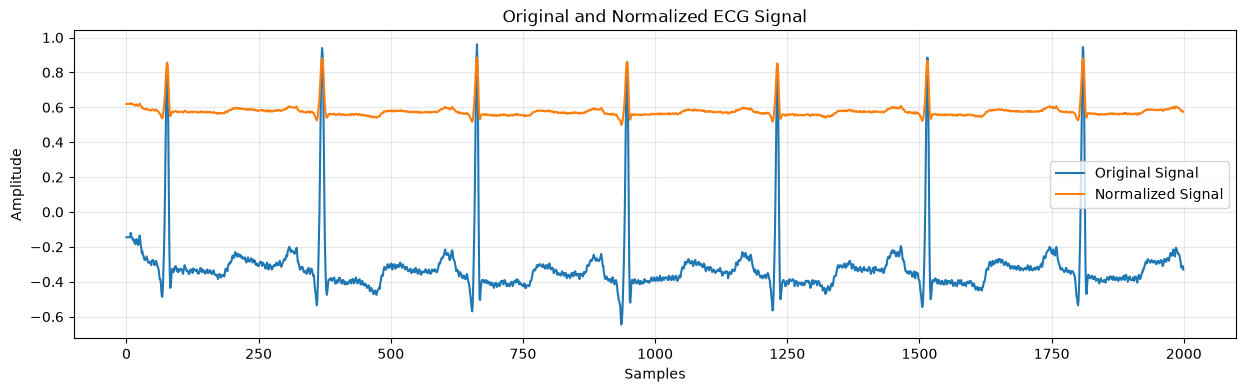

In [ ]:
# Compare original and normalized signals

plt.figure(figsize=(15, 4))

plt.plot(signal[:2000], label="Original Signal")

plt.plot(normalized_signal[:2000], label="Normalized Signal")

plt.title("Original and Normalized ECG Signal")

plt.xlabel("Samples")

plt.ylabel("Amplitude")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## What do we observe?

در این شکل، هر دو سیگنال اصلی و نرمال‌شده نمایش داده شده‌اند.

مشاهده می‌کنید که شکل کلی موج ECG تغییری نکرده است و تنها دامنه سیگنال به یک بازه استاندارد منتقل شده است.

به همین دلیل، اطلاعات اصلی سیگنال حفظ می‌شود و داده برای مراحل بعدی آماده‌تر خواهد بود.

## Window Selection

اکنون که سیگنال آماده شده است، باید هر ضربان قلب را به‌صورت جداگانه استخراج کنیم.

برای این کار از محل Annotationها استفاده می‌کنیم.

هر Annotation محل تقریبی یک R-Peak را مشخص می‌کند. بنابراین می‌توانیم اطراف هر R-Peak یک پنجره ثابت انتخاب کنیم و آن را به‌عنوان یک نمونه مستقل در نظر بگیریم.

در این مرحله هنوز ضربان‌ها را استخراج نمی‌کنیم؛ فقط بررسی می‌کنیم که پنجره انتخابی چگونه روی سیگنال قرار می‌گیرد.

In [ ]:
# Select one heartbeat window

peak = annotation.sample[10]

window_before = 100
window_after = 150

start = peak - window_before
end = peak + window_after

heartbeat = normalized_signal[start:end]

print("Window length:", len(heartbeat))

Window length: 250


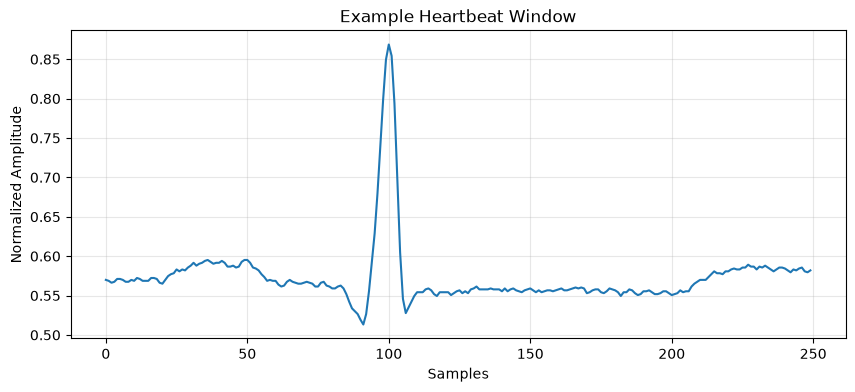

In [ ]:
# Visualize one heartbeat window

plt.figure(figsize=(10, 4))

plt.plot(heartbeat)

plt.title("Example Heartbeat Window")

plt.xlabel("Samples")

plt.ylabel("Normalized Amplitude")

plt.grid(alpha=0.3)

plt.show()

در این شکل، تنها یک ضربان قلب مشاهده می‌شود.

این نمونه از اطراف یک R-Peak استخراج شده است و دقیقاً همان نوع داده‌ای است که در مراحل بعدی برای ساخت مجموعه داده آموزشی استفاده خواهد شد.

در ادامه، همین فرآیند برای تمام ضربان‌های موجود در دیتاست تکرار می‌شود.

## Transition to Heartbeat Segmentation

تا اینجا، مراحل آماده‌سازی اولیه سیگنال انجام شد.

در این بخش یاد گرفتیم که:

- سیگنال ECG را نرمال‌سازی کنیم.
- دلیل استفاده از نرمال‌سازی را درک کنیم.
- مفهوم پنجره اطراف R-Peak را بشناسیم.
- یک نمونه از ضربان قلب را روی سیگنال مشاهده کنیم.

اکنون همه اطلاعات لازم برای استخراج سیستماتیک ضربان‌ها در اختیار ما قرار دارد.

در بخش بعدی، هر Annotation را به یک نمونه مستقل تبدیل می‌کنیم تا مجموعه داده موردنیاز برای آموزش مدل Autoencoder-CNN ساخته شود.

# 7. Heartbeat Segmentation

در این بخش، سیگنال پیوسته ECG را به مجموعه‌ای از ضربان‌های مستقل تبدیل می‌کنیم.

همان‌طور که در مرحله قبل مشاهده کردید، محل هر ضربان توسط فایل Annotation مشخص شده است. اکنون از این اطلاعات استفاده می‌کنیم تا برای هر ضربان، یک بازه زمانی ثابت از سیگنال استخراج کنیم.

در این پروژه، هر ضربان حول محور R-Peak استخراج می‌شود؛ زیرا R-Peak پایدارترین و مشخص‌ترین بخش چرخه قلب است.

این مرحله، مجموعه داده‌ای را ایجاد می‌کند که در مراحل بعدی برای آموزش مدل‌های یادگیری عمیق استفاده خواهد شد.

---

## Learning Objectives

پس از مطالعه این بخش، انتظار می‌رود بتوانید:

- مفهوم Heartbeat Segmentation را توضیح دهید.
- دلیل استفاده از R-Peak به عنوان مرکز هر ضربان را بیان کنید.
- هر ضربان را به‌صورت یک نمونه مستقل استخراج کنید.
- شکل موج ضربان‌های استخراج‌شده را بررسی کنید.

In [ ]:
# Define heartbeat window

samples_before = 90
samples_after = 180

window_size = samples_before + samples_after

print(f"Window size: {window_size} samples")

Window size: 270 samples


در این مرحله اندازه پنجره استخراج هر ضربان را مشخص می‌کنیم.

با توجه به نرخ نمونه‌برداری 360 هرتز:

- 90 نمونه قبل از R-Peak
- 180 نمونه بعد از R-Peak

استخراج می‌شود.

در نتیجه، هر ضربان شامل 270 نمونه خواهد بود.

این اندازه تقریباً یک چرخه کامل ECG را شامل می‌شود و در بسیاری از پژوهش‌های مبتنی بر دیتاست MIT-BIH نیز مورد استفاده قرار گرفته است.

In [ ]:
# Extract heartbeat segments

signal = record.p_signal[:, 0]

heartbeats = []

labels = []

for sample, symbol in zip(annotation.sample, annotation.symbol):

    start = sample - samples_before
    end = sample + samples_after

    if start >= 0 and end <= len(signal):

        beat = signal[start:end]

        heartbeats.append(beat)

        labels.append(symbol)

print("Extracted heartbeats:", len(heartbeats))

Extracted heartbeats: 2271


در این سلول، هر Annotation به یک نمونه مستقل از سیگنال تبدیل می‌شود.

برای هر R-Peak:

- ابتدای پنجره محاسبه می‌شود.
- انتهای پنجره تعیین می‌شود.
- در صورتی که پنجره از محدوده سیگنال خارج نباشد، ضربان استخراج می‌شود.

در کنار هر ضربان، برچسب مربوط به آن نیز ذخیره می‌شود تا در مراحل بعد برای آموزش مدل مورد استفاده قرار گیرد.

In [ ]:
# Convert heartbeats to NumPy array

heartbeats = np.array(heartbeats)

labels = np.array(labels)

print("Heartbeat array shape:", heartbeats.shape)

print("Label array shape:", labels.shape)

Heartbeat array shape: (2271, 270)
Label array shape: (2271,)


در این مرحله، داده‌ها به آرایه‌های NumPy تبدیل می‌شوند.

این قالب برای مراحل بعدی مانند:

- آماده‌سازی دیتاست
- آموزش Autoencoder
- آموزش CNN

مناسب‌تر است و سرعت پردازش را نیز افزایش می‌دهد.

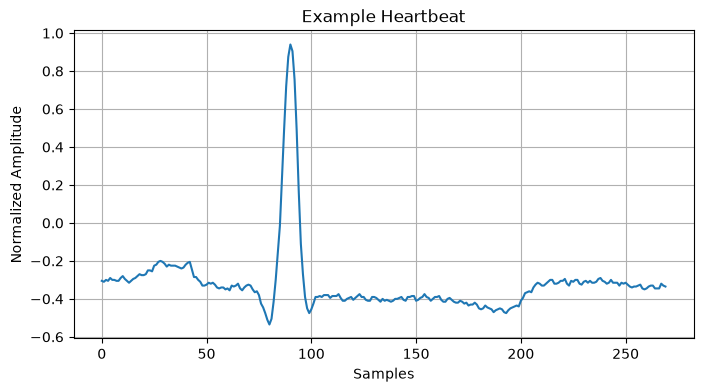

In [ ]:
# Plot a single heartbeat

plt.figure(figsize=(8,4))

plt.plot(heartbeats[0])

plt.title("Example Heartbeat")

plt.xlabel("Samples")

plt.ylabel("Normalized Amplitude")

plt.grid(True)

plt.show()

در شکل بالا، تنها یک ضربان قلب مشاهده می‌شود.

مرکز این سیگنال، محل تقریبی R-Peak است و بخش‌های قبل و بعد از آن، سایر قسمت‌های چرخه قلب را نشان می‌دهند.

از این مرحله به بعد، مدل دیگر با سیگنال پیوسته کار نمی‌کند؛ بلکه هر ضربان را به‌عنوان یک نمونه مستقل دریافت خواهد کرد.

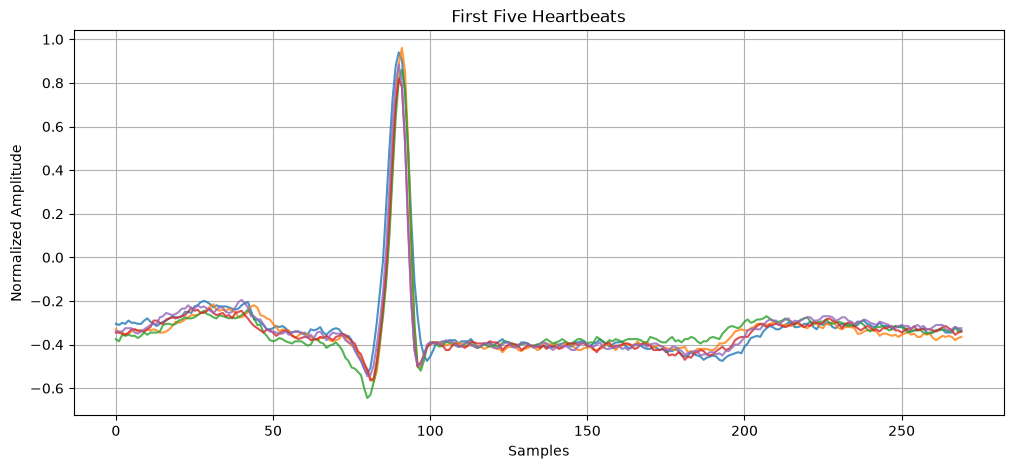

In [ ]:
# Plot several heartbeat samples

plt.figure(figsize=(12,5))

for i in range(5):

    plt.plot(heartbeats[i], alpha=0.8)

plt.title("First Five Heartbeats")

plt.xlabel("Samples")

plt.ylabel("Normalized Amplitude")

plt.grid(True)

plt.show()

با نمایش چند ضربان در کنار یکدیگر می‌توان مشاهده کرد که اگرچه شکل کلی چرخه‌های قلب مشابه است، اما تفاوت‌های کوچکی بین آن‌ها وجود دارد.

همین تفاوت‌ها اطلاعات ارزشمندی درباره نوع ضربان در اختیار مدل قرار می‌دهند و به مدل کمک می‌کنند تا بین ضربان‌های طبیعی و غیرطبیعی تمایز قائل شود.

In [ ]:
# Show first heartbeat labels

heartbeat_df = pd.DataFrame(
    {
        "Label": labels[:20]
    }
)

heartbeat_df

,Label
0,N
1,N
2,N
3,N
4,N
5,N
6,A
7,N
8,N
9,N


در این جدول، برچسب مربوط به چند ضربان اول نمایش داده شده است.

در ادامه پروژه، این برچسب‌ها به کلاس‌های استاندارد AAMI تبدیل خواهند شد تا فرآیند آموزش و ارزیابی مدل با استانداردهای رایج پژوهشی هماهنگ باشد.

## Key Takeaways

در این بخش:

- سیگنال ECG به مجموعه‌ای از ضربان‌های مستقل تقسیم شد.
- هر ضربان حول محور R-Peak استخراج شد.
- برای هر ضربان، برچسب مربوطه ذخیره شد.
- داده‌ها برای ورود به مرحله آماده‌سازی دیتاست آماده شدند.

در مرحله بعد، داده‌های استخراج‌شده را برای آموزش مدل آماده خواهیم کرد؛ از جمله انتخاب کلاس‌های مورد نظر، تبدیل برچسب‌ها و ساخت مجموعه‌های آموزش، اعتبارسنجی و آزمون.

# 8. Dataset Preparation

در این بخش، داده‌های استخراج‌شده را برای آموزش مدل آماده می‌کنیم.

در فایل Annotation همه نمادها نشان‌دهنده ضربان قلب نیستند؛ برخی از آن‌ها فقط رویدادهای ثبت سیگنال هستند.

بنابراین، ابتدا فقط ضربان‌هایی را انتخاب می‌کنیم که برای طبقه‌بندی آریتمی موردنیاز هستند.

این مرحله کیفیت مجموعه داده نهایی را به‌طور قابل‌توجهی افزایش می‌دهد.

In [ ]:
# Define valid heartbeat symbols

valid_symbols = [
    "N", "L", "R", "A", "a", "J",
    "S", "V", "E", "F", "Q"
]

filtered_df = annotation_df[
    annotation_df["symbol"].isin(valid_symbols)
].copy()

print(f"Total annotations : {len(annotation_df)}")
print(f"Valid heartbeats  : {len(filtered_df)}")

Total annotations : 2274
Valid heartbeats  : 2273


در خروجی بالا مشاهده می‌کنید که بخشی از Annotationها حذف شده‌اند.

دلیل این موضوع آن است که همه Annotationها مربوط به ضربان قلب نیستند.

از این مرحله به بعد، فقط ضربان‌هایی را نگه می‌داریم که در فرآیند طبقه‌بندی آریتمی استفاده خواهند شد.

7.2 Convert Labels to AAMI Classes

این قسمت از مهم‌ترین بخش‌های مقاله است.

مقاله دقیقاً از استاندارد AAMI استفاده کرده است.

یعنی ده‌ها نوع Beat موجود در MIT-BIH به پنج کلاس اصلی تبدیل می‌شوند:

![image.png](attachment:image.png)

دقیقاً همین پنج کلاس در جدول نتایج مقاله گزارش شده‌اند (N، SVEB، VEB، F و Q).

In [ ]:
# Convert MIT-BIH symbols to AAMI classes

aami_map = {
    "N": "N",
    "L": "N",
    "R": "N",

    "A": "SVEB",
    "a": "SVEB",
    "J": "SVEB",
    "S": "SVEB",

    "V": "VEB",
    "E": "VEB",

    "F": "F",

    "Q": "Q"
}

filtered_df["class"] = filtered_df["symbol"].map(aami_map)

filtered_df.head()

,sample,symbol,class
1,77,N,N
2,370,N,N
3,662,N,N
4,946,N,N
5,1231,N,N


برای کاهش تعداد کلاس‌ها و ایجاد یک استاندارد مشترک بین پژوهش‌ها، از نگاشت AAMI استفاده می‌کنیم.

در این استاندارد، چندین نوع ضربان مشابه در یک گروه قرار می‌گیرند.

به همین دلیل، مدل نهایی به‌جای یادگیری ده‌ها برچسب مختلف، تنها پنج کلاس اصلی را پیش‌بینی خواهد کرد.

In [ ]:
class_counts = filtered_df["class"].value_counts()

class_counts

class
N       2239
SVEB      33
VEB        1
Name: count, dtype: int64

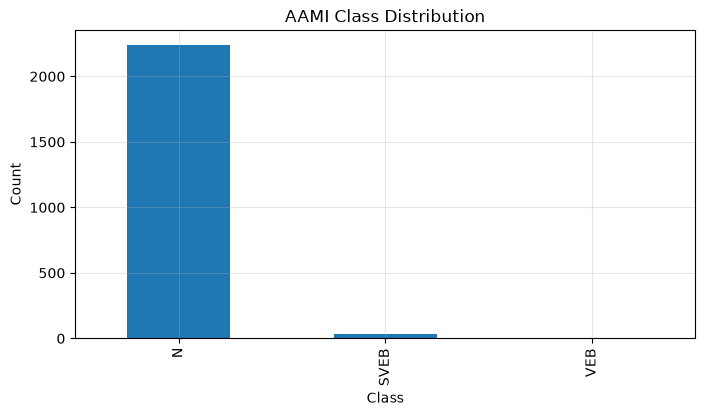

In [ ]:
plt.figure(figsize=(8, 4))

class_counts.plot(kind="bar")

plt.title("AAMI Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.grid(alpha=0.3)

plt.show()

اکنون توزیع کلاس‌ها را پس از تبدیل به استاندارد AAMI مشاهده می‌کنیم.

همان‌طور که انتظار می‌رود، کلاس **N** بیشترین تعداد نمونه را دارد، در حالی که کلاس‌های **F** و **Q** بسیار کم‌تعداد هستند.

این عدم توازن یکی از چالش‌های اصلی در طراحی مدل‌های طبقه‌بندی آریتمی است و در مرحله آموزش باید برای آن راهکار مناسبی در نظر گرفته شود.